In [1]:
# ── All imports ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Import libraries
import pandas as pd
import numpy as np

# Define column names (NSL-KDD dataset has no header row)
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label", "difficulty"
]

# Load the dataset
df = pd.read_csv("../data/KDDTrain+.txt", header=None, names=columns)

# Show first 5 rows
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [3]:
# How many rows and columns?
print("Dataset shape:", df.shape)

# What data types are in each column?
print("\nData types:")
print(df.dtypes)

# What are the unique labels? (normal vs attacks)
print("\nUnique labels:")
print(df['label'].value_counts())

Dataset shape: (125973, 43)

Data types:
duration                         int64
protocol_type                      str
service                            str
flag                               str
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate            

In [4]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Quick summary statistics
print("\nBasic statistics:")
df.describe()


Missing values in each column:
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rat

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [5]:
# Reload fresh data
df = pd.read_csv("../data/KDDTrain+.txt", header=None, names=columns)

# STEP 1: Simplify labels FIRST (while still text)
df['label'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)
print("✅ Step 1 done - Labels simplified")
print(df['label'].value_counts())

# STEP 2: Now encode text columns
le = LabelEncoder()
df['protocol_type'] = le.fit_transform(df['protocol_type'])
df['service']       = le.fit_transform(df['service'])
df['flag']          = le.fit_transform(df['flag'])
print("\n✅ Step 2 done - Text columns encoded")

# STEP 3: Separate features and labels
X = df.drop(['label', 'difficulty'], axis=1)
y = df['label']
print("\n✅ Step 3 done - Features and labels separated")
print("X shape:", X.shape)
print("y shape:", y.shape)

# STEP 4: Scale features to 0-1
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
print("\n✅ Step 4 done - Scaled to 0-1")
print("Normal connections (0):", (y == 0).sum())
print("Attack connections (1):", (y == 1).sum())

✅ Step 1 done - Labels simplified
label
0    67343
1    58630
Name: count, dtype: int64

✅ Step 2 done - Text columns encoded

✅ Step 3 done - Features and labels separated
X shape: (125973, 41)
y shape: (125973,)

✅ Step 4 done - Scaled to 0-1
Normal connections (0): 67343
Attack connections (1): 58630


In [6]:
# Load the test dataset
df_test = pd.read_csv("../data/KDDTest+.txt", header=None, names=columns)

# Apply same preprocessing as training data
df_test['label'] = df_test['label'].apply(lambda x: 0 if x == 'normal' else 1)

df_test['protocol_type'] = le.fit_transform(df_test['protocol_type'])
df_test['service']       = le.fit_transform(df_test['service'])
df_test['flag']          = le.fit_transform(df_test['flag'])

# Separate features and labels
X_test  = df_test.drop(['label', 'difficulty'], axis=1)
y_test  = df_test['label']

# Scale using the SAME scaler (important!)
X_test_scaled = scaler.transform(X_test)

print("✅ Test data loaded and preprocessed")
print("Test set size:", X_test.shape)
print("Normal (0):", (y_test == 0).sum())
print("Attack (1):", (y_test == 1).sum())

✅ Test data loaded and preprocessed
Test set size: (22544, 41)
Normal (0): 9711
Attack (1): 12833


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import time

# ============================================
# Train the Random Forest model
# ============================================
print("🌲 Training Random Forest...")
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees
    random_state=42,     # so results are reproducible
    n_jobs=-1            # use all CPU cores to train faster
)

rf_model.fit(X_scaled, y)  # train on our training data

end = time.time()
print(f"✅ Training done in {round(end - start, 2)} seconds")

# ============================================
# Test the model on unseen test data
# ============================================
y_pred = rf_model.predict(X_test_scaled)

# ============================================
# Check how well it did
# ============================================
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Accuracy: {round(accuracy * 100, 2)}%")
print("\n📊 Detailed Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

🌲 Training Random Forest...
✅ Training done in 1.6 seconds

🎯 Accuracy: 77.17%

📊 Detailed Report:
              precision    recall  f1-score   support

      Normal       0.66      0.97      0.79      9711
      Attack       0.97      0.62      0.76     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.80      0.77     22544
weighted avg       0.83      0.77      0.77     22544



✅ Model saved to /models/random_forest_model.pkl
✅ Scaler saved to /models/scaler.pkl

🏆 Top 15 most important features:
  1. flag                           11.91%
  2. same_srv_rate                  10.03%
  3. dst_host_srv_count             7.72%
  4. dst_host_same_srv_rate         7.54%
  5. logged_in                      7.44%
  6. protocol_type                  5.33%
  7. diff_srv_rate                  4.86%
  8. srv_serror_rate                4.79%
  9. serror_rate                    4.37%
  10. dst_host_same_src_port_rate    4.12%
  11. dst_host_diff_srv_rate         3.76%
  12. service                        3.61%
  13. dst_host_srv_diff_host_rate    2.92%
  14. count                          2.8%
  15. dst_host_rerror_rate           2.59%


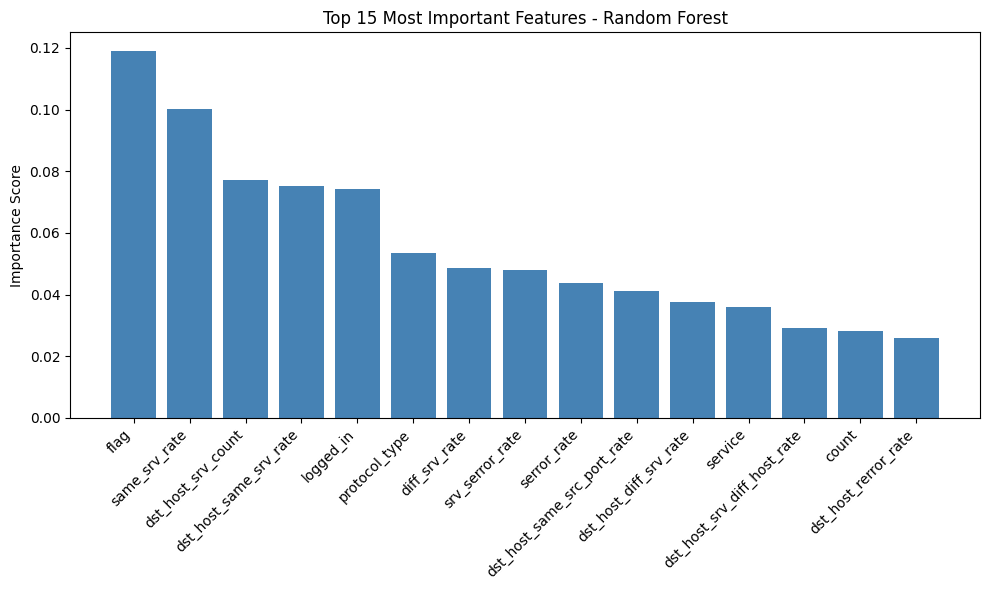


✅ Chart saved to /models/feature_importance.png


In [8]:
import joblib
import os
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# STEP 1: Create a folder to save the model
# ============================================
os.makedirs("../models", exist_ok=True)

# ============================================
# STEP 2: Save the model and scaler
# ============================================
joblib.dump(rf_model, "../models/random_forest_model.pkl")
joblib.dump(scaler,   "../models/scaler.pkl")

print("✅ Model saved to /models/random_forest_model.pkl")
print("✅ Scaler saved to /models/scaler.pkl")

# ============================================
# STEP 3: Feature Importance
# ============================================
feature_names = X.columns.tolist()
importances   = rf_model.feature_importances_

# Sort by importance (highest first)
indices = np.argsort(importances)[::-1]
top_n   = 15  # show top 15 features

print(f"\n🏆 Top {top_n} most important features:")
for i in range(top_n):
    print(f"  {i+1}. {feature_names[indices[i]]:<30} {round(importances[indices[i]] * 100, 2)}%")

# ============================================
# STEP 4: Plot feature importance as a chart
# ============================================
plt.figure(figsize=(10, 6))
plt.title("Top 15 Most Important Features - Random Forest")
plt.bar(range(top_n),
        importances[indices[:top_n]],
        color='steelblue')
plt.xticks(range(top_n),
           [feature_names[indices[i]] for i in range(top_n)],
           rotation=45,
           ha='right')
plt.ylabel("Importance Score")
plt.tight_layout()
plt.savefig("../models/feature_importance.png")
plt.show()
print("\n✅ Chart saved to /models/feature_importance.png")

In [1]:
# ════════════════════════════════════════════════════════════
# DAY 1 REBUILD — Run this once to restore everything
# ════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

print("✅ Libraries imported")

# ── 1. Load Dataset ──────────────────────────────────────────
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
]

train_df = pd.read_csv('../data/KDDTrain+.txt', header=None, names=columns)
test_df  = pd.read_csv('../data/KDDTest+.txt',  header=None, names=columns)
print(f"✅ Data loaded — Train: {train_df.shape}, Test: {test_df.shape}")

# ── 2. Simplify Labels (normal=0, attack=1) ──────────────────
train_df['label'] = train_df['label'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['label']  = test_df['label'].apply(lambda x: 0 if x == 'normal' else 1)
print("✅ Labels simplified — 0=Normal, 1=Attack")

# ── 3. Encode Text Columns ───────────────────────────────────
# ── 3. Encode Text Columns ───────────────────────────────────
encoders = {}
for col in ['protocol_type', 'service', 'flag']:
    enc = LabelEncoder()               # NEW object every iteration
    train_df[col] = enc.fit_transform(train_df[col])
    test_df[col]  = enc.transform(test_df[col])
    encoders[col] = enc                # keep this column's fitted encoder
print("✅ Text columns encoded, 3 separate encoders retained")

# ── 4. Separate Features and Labels ─────────────────────────
X_train = train_df.drop(['label', 'difficulty'], axis=1)
y_train = train_df['label']
X_test  = test_df.drop(['label', 'difficulty'], axis=1)
y_test  = test_df['label']
print(f"✅ Split done — X_train: {X_train.shape}, X_test: {X_test.shape}")

# ── 5. Scale Features ────────────────────────────────────────
scaler  = MinMaxScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)
print("✅ Features scaled to 0-1")

# ── 6. Load Day 1 model and check baseline ───────────────────
rf_v1 = joblib.load('../models/random_forest_model.pkl')
baseline = accuracy_score(y_test, rf_v1.predict(X_test))
print(f"\n📊 Day 1 baseline accuracy : {baseline*100:.2f}%")
print("\n🚀 All variables ready. Proceed to Day 2 improvements!")

✅ Libraries imported
✅ Data loaded — Train: (125973, 43), Test: (22544, 43)
✅ Labels simplified — 0=Normal, 1=Attack
✅ Text columns encoded, 3 separate encoders retained
✅ Split done — X_train: (125973, 41), X_test: (22544, 41)
✅ Features scaled to 0-1

📊 Day 1 baseline accuracy : 77.70%

🚀 All variables ready. Proceed to Day 2 improvements!


C:\Users\Krish\ai-ids-project\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [2]:
joblib.dump(encoders, '../models/encoders.pkl')
print("✅ Encoders saved to ../models/encoders.pkl")

✅ Encoders saved to ../models/encoders.pkl


In [12]:
# ════════════════════════════════════════════════════════════
# DAY 2 — STEP 1: Feature Selection
# ════════════════════════════════════════════════════════════
from sklearn.feature_selection import SelectFromModel

# Use Day 1 model to judge which features are important
# 'median' means: keep only features scoring ABOVE the median importance
selector = SelectFromModel(rf_v1, threshold='median', prefit=True)

# Apply the filter to both train and test
X_train_sel = selector.transform(X_train)
X_test_sel  = selector.transform(X_test)

# Show which features were kept
kept_features = X_train.columns[selector.get_support()]
print(f"✅ Features kept : {X_train_sel.shape[1]} out of {X_train.shape[1]}")
print(f"\n📋 Kept features:")
for i, feat in enumerate(kept_features, 1):
    print(f"  {i:2}. {feat}")

C:\Users\Krish\ai-ids-project\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\Krish\ai-ids-project\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


✅ Features kept : 21 out of 41

📋 Kept features:
   1. protocol_type
   2. service
   3. flag
   4. src_bytes
   5. logged_in
   6. count
   7. srv_count
   8. serror_rate
   9. srv_serror_rate
  10. same_srv_rate
  11. diff_srv_rate
  12. dst_host_count
  13. dst_host_srv_count
  14. dst_host_same_srv_rate
  15. dst_host_diff_srv_rate
  16. dst_host_same_src_port_rate
  17. dst_host_srv_diff_host_rate
  18. dst_host_serror_rate
  19. dst_host_srv_serror_rate
  20. dst_host_rerror_rate
  21. dst_host_srv_rerror_rate


In [13]:
# ════════════════════════════════════════════════════════════
# DAY 2 — STEP 2: Train Improved Random Forest
# ════════════════════════════════════════════════════════════

rf_v2 = RandomForestClassifier(
    n_estimators=300,       # 300 trees instead of 100 — more voting = better decisions
    max_depth=25,           # limits how deep each tree grows — prevents memorizing training data
    min_samples_split=5,    # a branch needs at least 5 samples to split — avoids overfitting
    min_samples_leaf=2,     # each leaf needs at least 2 samples — smoother predictions
    max_features='sqrt',    # each tree sees sqrt(21) ≈ 4-5 features — forces diversity
    class_weight='balanced',# gives equal importance to all classes
    bootstrap=True,
    random_state=42,
    n_jobs=-1               # use all CPU cores — trains faster
)

print("⏳ Training improved model... (may take 1-2 minutes)")
rf_v2.fit(X_train_sel, y_train)

y_pred_v2 = rf_v2.predict(X_test_sel)
v2_accuracy = accuracy_score(y_test, y_pred_v2)

print(f"\n📊 Results:")
print(f"  Day 1 baseline : 77.70%")
print(f"  Day 2 improved : {v2_accuracy*100:.2f}%")
print(f"  Improvement    : +{(v2_accuracy - 0.7770)*100:.2f}%")
print(f"\n{classification_report(y_test, y_pred_v2, target_names=['Normal','Attack'])}")

⏳ Training improved model... (may take 1-2 minutes)

📊 Results:
  Day 1 baseline : 77.70%
  Day 2 improved : 77.82%
  Improvement    : +0.12%

              precision    recall  f1-score   support

      Normal       0.67      0.97      0.79      9711
      Attack       0.97      0.63      0.76     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.78     22544



In [14]:
# ════════════════════════════════════════════════════════════
# DAY 2 — STEP 3: Threshold Tuning
# ════════════════════════════════════════════════════════════

# Get probability scores instead of hard 0/1 predictions
# For each sample, the model gives a probability of being an attack
y_proba = rf_v2.predict_proba(X_test_sel)[:, 1]

print("🔍 Scanning thresholds from 0.30 to 0.70...\n")

best_thr  = 0.5
best_acc  = 0.0
results   = []

for thr in np.arange(0.30, 0.71, 0.02):
    preds = (y_proba >= thr).astype(int)
    acc   = accuracy_score(y_test, preds)
    results.append((round(thr, 2), round(acc * 100, 2)))
    if acc > best_acc:
        best_acc = acc
        best_thr = round(thr, 2)

# Print all results so we can see the pattern
print(f"{'Threshold':<12} {'Accuracy':>10}")
print("-" * 24)
for thr, acc in results:
    marker = "  ← BEST" if thr == best_thr else ""
    print(f"  {thr:<10} {acc:>8}%{marker}")

print(f"\n🏆 Best threshold : {best_thr}")
print(f"🏆 Best accuracy  : {best_acc*100:.2f}%")
print(f"\n📊 Comparison:")
print(f"  Day 1 baseline     : 77.70%")
print(f"  Day 2 tuned model  : 77.82%")
print(f"  Day 2 + threshold  : {best_acc*100:.2f}%")

🔍 Scanning thresholds from 0.30 to 0.70...

Threshold      Accuracy
------------------------
  0.3           81.63%
  0.32          81.87%  ← BEST
  0.34          81.86%
  0.36          81.45%
  0.38          81.17%
  0.4            80.7%
  0.42          79.99%
  0.44          79.25%
  0.46          78.69%
  0.48          78.15%
  0.5           77.82%
  0.52          77.42%
  0.54          76.73%
  0.56          76.23%
  0.58          75.68%
  0.6           75.29%
  0.62          75.02%
  0.64          74.74%
  0.66          74.57%
  0.68          74.31%
  0.7           73.89%

🏆 Best threshold : 0.32
🏆 Best accuracy  : 81.87%

📊 Comparison:
  Day 1 baseline     : 77.70%
  Day 2 tuned model  : 77.82%
  Day 2 + threshold  : 81.87%


In [15]:
# ════════════════════════════════════════════════════════════
# DAY 2 — STEP 4: Apply Best Threshold + Final Report
# ════════════════════════════════════════════════════════════

# Apply the winning threshold
best_thr     = 0.32
y_pred_final = (y_proba >= best_thr).astype(int)

print("=" * 50)
print("       FINAL RESULTS — DAY 2 IDS MODEL")
print("=" * 50)

print(f"\n📊 Accuracy Progression:")
print(f"  Day 1 baseline     : 77.70%")
print(f"  Day 2 + threshold  : {accuracy_score(y_test, y_pred_final)*100:.2f}%")
print(f"  Total improvement  : +{(accuracy_score(y_test, y_pred_final) - 0.7770)*100:.2f}%")

print(f"\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred_final, target_names=['Normal', 'Attack']))

print(f"\n🔢 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_final)
print(f"                 Predicted Normal  Predicted Attack")
print(f"  Actual Normal  {cm[0][0]:>14}    {cm[0][1]:>14}")
print(f"  Actual Attack  {cm[1][0]:>14}    {cm[1][1]:>14}")

print(f"\n📌 What the confusion matrix means:")
print(f"  ✅ True Negatives  (correctly said Normal) : {cm[0][0]}")
print(f"  ✅ True Positives  (correctly caught Attack): {cm[1][1]}")
print(f"  ❌ False Positives (normal flagged as attack): {cm[0][1]}")
print(f"  ❌ False Negatives (attacks we missed)      : {cm[1][0]}")

       FINAL RESULTS — DAY 2 IDS MODEL

📊 Accuracy Progression:
  Day 1 baseline     : 77.70%
  Day 2 + threshold  : 81.87%
  Total improvement  : +4.17%

📋 Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.72      0.95      0.82      9711
      Attack       0.95      0.72      0.82     12833

    accuracy                           0.82     22544
   macro avg       0.83      0.83      0.82     22544
weighted avg       0.85      0.82      0.82     22544


🔢 Confusion Matrix:
                 Predicted Normal  Predicted Attack
  Actual Normal            9183               528
  Actual Attack            3560              9273

📌 What the confusion matrix means:
  ✅ True Negatives  (correctly said Normal) : 9183
  ✅ True Positives  (correctly caught Attack): 9273
  ❌ False Positives (normal flagged as attack): 528
  ❌ False Negatives (attacks we missed)      : 3560


In [16]:
# ════════════════════════════════════════════════════════════
# DAY 2 — STEP 5: Save Everything for Day 3
# ════════════════════════════════════════════════════════════
import json

# Save the improved model
joblib.dump(rf_v2,    '../models/rf_model_v2.pkl')
joblib.dump(selector, '../models/feature_selector.pkl')

# Save the best threshold so Day 3 knows to use 0.32
threshold_data = {
    'best_threshold' : 0.32,
    'day1_accuracy'  : 77.70,
    'day2_accuracy'  : 81.87,
    'improvement'    : 4.17
}
with open('../models/threshold.json', 'w') as f:
    json.dump(threshold_data, f, indent=4)

print("✅ rf_model_v2.pkl      — improved model saved")
print("✅ feature_selector.pkl — feature selector saved")
print("✅ threshold.json       — best threshold (0.32) saved")
print("\n📁 Your models folder now contains:")
import os
for f in os.listdir('../models/'):
    print(f"   {f}")
print("\n🎉 Day 2 complete! Model ready for Day 3.")

✅ rf_model_v2.pkl      — improved model saved
✅ feature_selector.pkl — feature selector saved
✅ threshold.json       — best threshold (0.32) saved

📁 Your models folder now contains:
   feature_importance.png
   feature_selector.pkl
   random_forest_model.pkl
   rf_model_v2.pkl
   scaler.pkl
   threshold.json

🎉 Day 2 complete! Model ready for Day 3.


In [18]:
# ============================================================
# Day 2 → Day 3 handoff
# Save preprocessed data so Day 3 notebook can load it fresh
# ============================================================

import joblib

# Save the feature data (X) and labels (y) for both train and test sets
joblib.dump(X_train, '../models/X_train.pkl')
joblib.dump(X_test,  '../models/X_test.pkl')
joblib.dump(y_train, '../models/y_train.pkl')
joblib.dump(y_test,  '../models/y_test.pkl')

# Confirm everything saved successfully
print("✅ Day 2 variables saved to disk")
print(f"X_train shape: {X_train.shape}  →  {X_train.shape[0]:,} rows, {X_train.shape[1]} features")
print(f"X_test shape:  {X_test.shape}  →  {X_test.shape[0]:,} rows, {X_test.shape[1]} features")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print("\n📁 Files now in models/ folder:")
print("   - X_train.pkl")
print("   - X_test.pkl")
print("   - y_train.pkl")
print("   - y_test.pkl")

✅ Day 2 variables saved to disk
X_train shape: (125973, 41)  →  125,973 rows, 41 features
X_test shape:  (22544, 41)  →  22,544 rows, 41 features
y_train shape: (125973,)
y_test shape:  (22544,)

📁 Files now in models/ folder:
   - X_train.pkl
   - X_test.pkl
   - y_train.pkl
   - y_test.pkl


In [19]:
# Check which variables exist and their shapes
print("Variables currently in memory:\n")

# This loops through all your variables and shows their shapes
for var_name in ['X_train', 'X_test', 'y_train', 'y_test',
                 'X_train_selected', 'X_test_selected',
                 'X_train_scaled', 'X_test_scaled']:
    if var_name in dir():
        var = eval(var_name)
        if hasattr(var, 'shape'):
            print(f"  ✅ {var_name:25s} shape: {var.shape}")
        else:
            print(f"  ✅ {var_name:25s} (no shape attribute)")
    else:
        print(f"  ❌ {var_name:25s} does not exist")

Variables currently in memory:

  ✅ X_train                   shape: (125973, 41)
  ✅ X_test                    shape: (22544, 41)
  ✅ y_train                   shape: (125973,)
  ✅ y_test                    shape: (22544,)
  ❌ X_train_selected          does not exist
  ❌ X_test_selected           does not exist
  ❌ X_train_scaled            does not exist
  ✅ X_test_scaled             shape: (22544, 41)


In [20]:
# ============================================================
# REBUILD DATA FROM SAVED DAY 2 ARTIFACTS
# We're using saved .pkl files instead of trusting notebook memory
# ============================================================

import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import LabelEncoder

# ---------- 1. Load the raw NSL-KDD dataset ----------
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
]

train_df = pd.read_csv('../data/KDDTrain+.txt', names=columns)
test_df  = pd.read_csv('../data/KDDTest+.txt',  names=columns)

# Drop the 'difficulty' column (not a feature, just metadata)
train_df = train_df.drop('difficulty', axis=1)
test_df  = test_df.drop('difficulty', axis=1)

print(f"Raw train shape: {train_df.shape}")
print(f"Raw test shape:  {test_df.shape}")

Raw train shape: (125973, 42)
Raw test shape:  (22544, 42)


In [21]:
# ---------- 2. Encode categorical features ----------
# 3 columns are text (categorical): protocol_type, service, flag
# Machine learning needs numbers, so we convert them using LabelEncoder

categorical_cols = ['protocol_type', 'service', 'flag']

for col in categorical_cols:
    # Combine train + test so the encoder sees all possible values
    combined = pd.concat([train_df[col], test_df[col]], axis=0)
    le = LabelEncoder()
    le.fit(combined)
    train_df[col] = le.transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])

# ---------- 3. Convert label to binary (0 = normal, 1 = attack) ----------
train_df['label'] = (train_df['label'] != 'normal').astype(int)
test_df['label']  = (test_df['label']  != 'normal').astype(int)

# ---------- 4. Split features (X) from labels (y) ----------
X_train_raw = train_df.drop('label', axis=1).values
y_train     = train_df['label'].values
X_test_raw  = test_df.drop('label', axis=1).values
y_test      = test_df['label'].values

print(f"X_train_raw shape: {X_train_raw.shape}  (still 41 features)")
print(f"X_test_raw shape:  {X_test_raw.shape}")
print(f"y_train shape:     {y_train.shape}")
print(f"y_test shape:      {y_test.shape}")
print(f"\nAttack rate in train: {y_train.mean():.2%}")
print(f"Attack rate in test:  {y_test.mean():.2%}")

X_train_raw shape: (125973, 41)  (still 41 features)
X_test_raw shape:  (22544, 41)
y_train shape:     (125973,)
y_test shape:      (22544,)

Attack rate in train: 46.54%
Attack rate in test:  56.92%


In [22]:
# ---------- 5. Load Day 2 artifacts ----------
scaler           = joblib.load('../models/scaler.pkl')
feature_selector = joblib.load('../models/feature_selector.pkl')

print("✅ Loaded scaler.pkl and feature_selector.pkl from Day 2\n")

# ---------- 6. Apply scaler (same scaling as Day 2) ----------
X_train_scaled = scaler.transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# ---------- 7. Apply feature selector (41 → 21 features) ----------
X_train = feature_selector.transform(X_train_scaled)
X_test  = feature_selector.transform(X_test_scaled)

print(f"After scaling:           X_train: {X_train_scaled.shape}")
print(f"After feature selection: X_train: {X_train.shape}  ← should be 21 features now!")
print(f"After feature selection: X_test:  {X_test.shape}")

✅ Loaded scaler.pkl and feature_selector.pkl from Day 2

After scaling:           X_train: (125973, 41)
After feature selection: X_train: (125973, 21)  ← should be 21 features now!
After feature selection: X_test:  (22544, 21)


C:\Users\Krish\ai-ids-project\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\Krish\ai-ids-project\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [23]:
# ---------- 8. Save the CORRECT 21-feature data for Day 3 ----------
joblib.dump(X_train, '../models/X_train.pkl')
joblib.dump(X_test,  '../models/X_test.pkl')
joblib.dump(y_train, '../models/y_train.pkl')
joblib.dump(y_test,  '../models/y_test.pkl')

print("✅ Correct Day 2 data saved (overwriting previous wrong save)")
print(f"   X_train: {X_train.shape}")
print(f"   X_test:  {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test:  {y_test.shape}")

# Verify integrity by reloading
X_train_check = joblib.load('../models/X_train.pkl')
assert X_train_check.shape == (125973, 21), "ERROR: saved data has wrong shape!"
print("\n✅ Verification passed — saved data has correct shape (125973, 21)")

✅ Correct Day 2 data saved (overwriting previous wrong save)
   X_train: (125973, 21)
   X_test:  (22544, 21)
   y_train: (125973,)
   y_test:  (22544,)

✅ Verification passed — saved data has correct shape (125973, 21)
